# Zero-spend fuzzy fair-baseline re-analysis: certificate vs. confidence threshold

**Artifact `art_0MDLD-w-RXOu`** — a `$0`-LLM, pure `numpy` re-analysis from the paper
*"No Derivation, No Relation: a closure certificate for LLM-extracted relations."*

The paper claims a **structural, label-free certificate** that abstains on logical *collapse*
catches confident relational hallucinations that a plain **confidence threshold cannot see**.
A reviewer pushed back (MAJOR #2): the original comparator was an *always-answer* baseline
(confident-wrong `0.000` vs `0.364`), which is unfair. This evaluation builds the **fair**
comparator — a **confidence-thresholded top-1 abstainer at matched coverage** — and asks:
does the certificate still win?

**The only new computation (TASK 1):** for each fuzzy setting (spatial RCC-8, kinship
paraphrase) we take the LLM's per-edge-read top-1 confidences, commit the `k = round(cov·N)`
most-confident reads (matching the certificate's coverage), measure the resulting
**confident-wrong** rate, and put a **doc-clustered bootstrap** CI on it. If the lower bound
excludes 0, the certificate (`confident-wrong = 0.000`) **beats** the fair baseline.

Deterministic: `seed = 20260617`, doc-clustered bootstrap. This demo runs the verbatim
re-analysis on a **curated 100-edge-read subset** loaded from GitHub (the full eval uses
1500 calibration reads / setting). Parameters live in the **Config** cell and are set to
small demo values; comments show the originals.

> *Skipped in this self-contained demo:* the full `eval.py` opens with two reproduce-verify
> **gates** (STEP 0 vs the iter-4/iter-5 eval outputs; carried-literal verify vs the
> CLUTRR/SPATIAL source files). Those compare against other experiment workspaces that are
> not bundled here, so we focus on TASK 1 (the new computation) and the static framing
> deliverables TASK 2/3/4.

In [1]:
# --- Install dependencies (works on Colab and locally) ---
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# loguru is NOT pre-installed on Colab -> always install
_pip('loguru==0.7.3')

# numpy + matplotlib ARE pre-installed on Colab; install locally only (Colab's exact versions)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# --- Imports (original module header) + matplotlib for the demo viz ---
from __future__ import annotations

import gc
import json
import resource
import sys
from pathlib import Path

import numpy as np
from loguru import logger
import matplotlib.pyplot as plt

# Logging (stdout) -- mirrors the original eval.py setup
logger.remove()
logger.add(sys.stdout, level="INFO", format="{time:HH:mm:ss}|{level:<7}|{message}")
Path("logs").mkdir(exist_ok=True)
logger.add("logs/run.log", rotation="30 MB", level="DEBUG")

# The original sets a 6 GB virtual-address (RLIMIT_AS) guard for the server run.
# In a shared notebook kernel that cap can collide with BLAS/threading virtual
# reservations, so we leave it commented out for the demo (the computation is tiny).
# _RAM_BUDGET = 6 * 1024 ** 3
# resource.setrlimit(resource.RLIMIT_AS, (_RAM_BUDGET, _RAM_BUDGET))

2

In [3]:
# --- Load the curated demo subset (GitHub URL with local fallback) ---
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-40a89b-no-derivation-no-relation-a-closure-cert/main/round-6/evaluation-1/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print("top-level keys:", list(data.keys()))
print("datasets:", [(x["dataset"], len(x["examples"])) for x in data["datasets"]])
print("metadata keys:", list(data["metadata"].keys()))

top-level keys: ['metadata', 'datasets']
datasets: [('spatial_fuzzy_rcc8', 60), ('kinship_fuzzy_paraphrase', 40)]
metadata keys: ['method_name', 'tag', 'seed', 'setting1_spatial_calibration', 'setting1_spatial_risk_coverage', 'setting2_kinship_calibration', 'setting2_kinship_risk_coverage']


## Config

All tunable parameters. Demo values are deliberately small; the original full-eval values
are shown in comments. `B_BOOT`, `ALPHA`, `N_EXAMPLE_CAP` and `SEED` are module-level globals
that the verbatim functions below read directly (exactly as in `eval.py`).

In [5]:
SEED = 20260617          # deterministic seed (original)
B_BOOT = 10000           # bootstrap replicates (original full-eval value; fits the demo budget)
ALPHA = 0.05             # 95% CIs (original)
N_EXAMPLE_CAP = 300      # per-dataset emitted records (original; the subset has fewer reads anyway)

# Matched coverage = the certificate's realized coverage on each query pool (carried,
# data-independent literals). The fair baseline commits k = round(cov * N) reads.
SPATIAL_MATCHED_COV = 0.5350877192982456   # spatial RCC-8 (122 / 228 queries)
KINSHIP_MATCHED_COV = 0.3139190523198421   # kinship paraphrase (318 / 1013 queries)

## Helper functions (verbatim from `eval.py`)

Small numpy utilities: pull aligned arrays out of the edge-read records, group read-indices
by document for the **doc-clustered** bootstrap, select the `k` most-confident reads
(`select_topk`, with a fixed-seed tie-break that never crosses a confidence level), and the
clustered bootstrap of the matched-coverage confident-wrong rate.

In [6]:
def approx(a, b, tol=1e-4) -> bool:
    """Numeric closeness with NaN/None handling."""
    if a is None or b is None:
        return a == b
    try:
        return abs(float(a) - float(b)) <= tol
    except (TypeError, ValueError):
        return a == b


def edge_reads(dataset: dict) -> list[dict]:
    return [e for e in dataset["examples"] if e.get("metadata_record_kind") == "edge_read"]


def to_arrays(reads: list[dict], gold_key: str, term_key: str):
    """Extract aligned numpy arrays from a list of edge_read records."""
    conf = np.array([float(r["metadata_top1_conf"]) for r in reads], dtype=np.float64)
    correct = np.array([bool(r["metadata_top1_correct"]) for r in reads], dtype=bool)
    sound = np.array([bool(r["metadata_sound"]) for r in reads], dtype=bool)
    breadth = np.array([float(r.get("metadata_breadth", np.nan)) for r in reads], dtype=np.float64)
    doc_ids = np.array([str(r["metadata_doc_id"]) for r in reads])
    gold = [str(r.get(gold_key, "")) for r in reads]
    term = [str(r.get(term_key, "")) for r in reads]
    top1 = [str(r.get("predict_top1", "")) for r in reads]
    inp = [str(r.get("input", "")) for r in reads]
    return conf, correct, sound, breadth, doc_ids, gold, term, top1, inp


def build_doc_matrix(doc_ids: np.ndarray):
    """Padded (D, maxlen) matrix of read-indices grouped by doc (for clustered bootstrap)."""
    docs, inv = np.unique(doc_ids, return_inverse=True)
    d = len(docs)
    counts = np.bincount(inv, minlength=d)
    maxlen = int(counts.max())
    mat = np.full((d, maxlen), -1, dtype=np.int64)
    pos = np.zeros(d, dtype=np.int64)
    for ridx in range(len(doc_ids)):
        di = inv[ridx]
        mat[di, pos[di]] = ridx
        pos[di] += 1
    return mat, d


def select_topk(conf: np.ndarray, correct: np.ndarray, k: int, tiekey: np.ndarray):
    """Commit the k most-confident reads; discrete-conf ties broken by tiekey (fixed seed).

    sortkey = -conf + 0.05*tiekey  (tiekey in [0,1); 0.05 < min conf gap 0.1, so ties
    never cross a confidence level). Smallest sortkey == highest conf == committed first.
    """
    sk = -conf + 0.05 * tiekey
    order = np.argsort(sk, kind="stable")
    committed = order[:k]
    cw = float(np.mean(~correct[committed])) if k > 0 else 0.0
    implied_tau = float(conf[committed[-1]]) if k > 0 else None
    return committed, cw, implied_tau


def doc_clustered_bootstrap_cw(conf, correct, mat, d, cov, tiekey, b_boot, rng):
    """Doc-clustered bootstrap of the matched-coverage confident-wrong rate.

    Each replicate resamples d doc-clusters with replacement, re-selects the
    k'=round(cov*N') most-confident reads, recomputes confident-wrong.
    """
    boot = np.empty(b_boot, dtype=np.float64)
    not_correct = ~correct
    for b in range(b_boot):
        sampled = rng.integers(0, d, size=d)
        rows = mat[sampled]                 # (d, maxlen)
        flat = rows[rows >= 0]              # variable length read indices
        n_p = flat.size
        kk = int(round(cov * n_p))
        if kk <= 0:
            boot[b] = 0.0
            continue
        c = conf[flat]
        sk = -c + 0.05 * tiekey[flat]
        if kk >= n_p:
            sel = flat
        else:
            part = np.argpartition(sk, kk - 1)[:kk]
            sel = flat[part]
        boot[b] = float(np.mean(not_correct[sel]))
    return boot

## Ground-truth literal gate (verbatim)

Before the new computation, assert the carried FUZZY ground-truth literals (certificate
coverage, commit-argmax confident-wrong, pool sizes, unsound-read counts) so the re-analysis
is provably reading the intended numbers. These live in the trimmed `metadata` block of the
demo subset and are checked verbatim.

In [7]:
def assert_ground_truth(md):
    s1 = md["setting1_spatial_risk_coverage"]
    s2 = md["setting2_kinship_risk_coverage"]
    assert approx(s1["certificate"]["coverage"], 0.5350877192982456, 1e-12), "spatial cert coverage"
    assert approx(s1["commit_argmax"]["confident_wrong_rate"], 0.36403508771929827, 1e-12), "spatial argmax CW"
    assert int(s1["commit_argmax"]["n_confident_wrong"]) == 83, "spatial argmax n_confident_wrong"
    assert int(s1["n_pool"]) == 228, "spatial n_pool"
    assert int(s1["n_unsound_reads"]) == 5, "spatial n_unsound"
    assert approx(s1["certificate"]["confident_wrong_rate"], 0.0, 1e-12), "spatial cert CW"
    assert approx(s2["certificate"]["coverage"], 0.3139190523198421, 1e-12), "kinship cert coverage"
    assert approx(s2["commit_argmax"]["confident_wrong_rate"], 0.21618953603158933, 1e-12), "kinship argmax CW"
    assert int(s2["commit_argmax"]["n_confident_wrong"]) == 219, "kinship argmax n_confident_wrong"
    assert int(s2["n_pool"]) == 1013, "kinship n_pool"
    assert int(s2["n_unsound_reads"]) == 0, "kinship n_unsound"
    logger.info("FUZZY ground-truth literals: ALL ASSERTIONS PASS")


assert_ground_truth(data["metadata"])

22:55:13|INFO   |FUZZY ground-truth literals: ALL ASSERTIONS PASS


## TASK 1 — confidence-thresholded fair baseline (the only new computation)

`task1_setting` builds, for one setting: the matched-coverage confidence-thresholded top-1
abstainer (point estimate + doc-clustered bootstrap CI + `certificate_beats` flag), the full
risk-coverage frontier, the hard-`tau` overshoot, the **Mode-B** sound-violation catch
quantification, and per-read records. `build_table3` assembles the per-setting Table 3.
Both are copied verbatim — the only edit is relaxing the hard `n == 1500` edge-read assert,
since the demo runs on a curated subset.

In [8]:
def task1_setting(name, dataset, matched_cov, gold_key, term_key,
                  rc_meta, ece_top1, rng):
    """Build the confidence-thresholded top-1 abstainer for one setting."""
    reads = edge_reads(dataset)
    n = len(reads)
    # Original full eval asserts EXACTLY 1500 calibration edge-reads per setting.
    # This demo runs on a curated subset, so we just record the count.
    assert n >= 1, f"{name}: no edge_reads found"
    conf, correct, sound, breadth, doc_ids, gold, term, top1, inp = to_arrays(reads, gold_key, term_key)

    tiekey = rng.random(n)  # fixed-seed permutation-equivalent tie-break
    k = int(round(matched_cov * n))
    committed_idx, baseline_cw, implied_tau = select_topk(conf, correct, k, tiekey)
    achieved_cov = k / n
    committed_mask = np.zeros(n, dtype=bool)
    committed_mask[committed_idx] = True

    # hard-tau overshoot (conf >= implied_tau commits ALL ties -> overshoots coverage)
    over_mask = conf >= (implied_tau - 1e-9)
    overshoot_cov = float(over_mask.mean())
    overshoot_cw = float(np.mean(~correct[over_mask])) if over_mask.any() else 0.0

    # full risk-coverage frontier (point estimates)
    grid = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
    frontier = []
    for c in grid:
        kc = int(round(c * n))
        kc = max(0, min(kc, n))
        if kc == 0:
            frontier.append({"coverage_target": c, "achieved_coverage": 0.0,
                             "confident_wrong": 0.0, "acc_among_answered": None, "k": 0})
            continue
        _, cw_c, _ = select_topk(conf, correct, kc, tiekey)
        frontier.append({"coverage_target": c, "achieved_coverage": kc / n,
                         "confident_wrong": cw_c, "acc_among_answered": 1.0 - cw_c, "k": kc})
    # add the exact matched point flagged
    frontier.append({"coverage_target": round(matched_cov, 7), "achieved_coverage": achieved_cov,
                     "confident_wrong": baseline_cw, "acc_among_answered": 1.0 - baseline_cw,
                     "k": k, "matched_point": True})

    # doc-clustered bootstrap on the matched-coverage CW
    mat, d_docs = build_doc_matrix(doc_ids)
    logger.info(f"{name}: matched_cov={matched_cov:.7f} N={n} k={k} implied_tau={implied_tau} "
                f"baseline_CW={baseline_cw:.4f} n_docs={d_docs}; running B={B_BOOT} clustered bootstrap")
    boot = doc_clustered_bootstrap_cw(conf, correct, mat, d_docs, matched_cov, tiekey, B_BOOT, rng)
    ci_lo = float(np.percentile(boot, 100 * ALPHA / 2))
    ci_hi = float(np.percentile(boot, 100 * (1 - ALPHA / 2)))
    p_one_sided = float(np.mean(boot <= 0.0))  # P(baseline_CW <= 0)
    certificate_beats = bool(ci_lo > 0.0)
    logger.info(f"{name}: bootstrap CW CI95=[{ci_lo:.4f},{ci_hi:.4f}] p(CW<=0)={p_one_sided:.4g} "
                f"certificate_beats={certificate_beats}")

    # Mode-B distinctive-edge quantification (edge-read level)
    n_unsound_edgeread = int((~sound).sum())
    unsound_conf = conf[~sound]
    unsound_conf_dist = {}
    for cv in np.unique(unsound_conf):
        unsound_conf_dist[str(round(float(cv), 4))] = int((unsound_conf == cv).sum())
    n_unsound_in_committed = int((committed_mask & ~sound).sum())
    # all unsound reads are top1-wrong by construction (gold not in emitted set)
    n_unsound_top1_wrong = int((~sound & ~correct).sum())

    # query-pool Mode-B (carried from rc_meta): queries whose chain dropped gold
    n_unsound_query = int(rc_meta["n_unsound_reads"])
    caught_frac = rc_meta.get("certificate_caught_fraction")
    n_caught = int(round(caught_frac * n_unsound_query)) if caught_frac is not None else 0
    n_silent_missed = int(rc_meta["n_silent_wrong_missed_by_cert"])

    setting = {
        "certificate": {
            "coverage": float(rc_meta["certificate"]["coverage"]),
            "confident_wrong": float(rc_meta["certificate"]["confident_wrong_rate"]),
            "n_committed": int(rc_meta["certificate"]["n_committed"]),
            "acc_among_answered": rc_meta["certificate"]["acc_among_answered"],
            "evidence_tag": "REAL-LLM-FUZZY-READ",
        },
        "commit_argmax": {
            "coverage": float(rc_meta["commit_argmax"]["coverage"]),
            "confident_wrong": float(rc_meta["commit_argmax"]["confident_wrong_rate"]),
            "n_confident_wrong": int(rc_meta["commit_argmax"]["n_confident_wrong"]),
            "acc_among_answered": rc_meta["commit_argmax"]["acc_among_answered"],
            "note": "ALWAYS-ANSWER contrast; NOT a fair abstainer.",
            "evidence_tag": "REAL-LLM-FUZZY-READ",
        },
        "conf_threshold_baseline": {
            "unit_of_analysis": "edge_read (1500 calibration reads); query records carry no per-query confidence",
            "construction": "top-k selection (k=round(cov*N)) on discrete top1_conf with fixed-seed tie-break",
            "matched_coverage": float(matched_cov),
            "achieved_coverage": float(achieved_cov),
            "k_committed": int(k),
            "implied_tau": implied_tau,
            "confident_wrong": float(baseline_cw),
            "acc_among_answered": float(1.0 - baseline_cw),
            "ci95": [ci_lo, ci_hi],
            "p_one_sided_cw_le_0": p_one_sided,
            "n_docs": int(d_docs),
            "certificate_beats": certificate_beats,
            "hard_tau_overshoot": {
                "note": "a hard conf>=tau cut commits ALL ties -> overshoots matched coverage",
                "overshoot_coverage": overshoot_cov,
                "overshoot_confident_wrong": overshoot_cw,
            },
            "frontier": frontier,
            "evidence_tag": "REAL-LLM-FUZZY-READ",
        },
        "modeB": {
            "n_unsound_query_pool": n_unsound_query,
            "n_caught": n_caught,
            "n_silent_wrong_missed": n_silent_missed,
            "certificate_caught_fraction": caught_frac,
            "n_unsound_edgeread": n_unsound_edgeread,
            "unsound_edgeread_conf_dist": unsound_conf_dist,
            "unsound_reads_all_high_conf": (bool(unsound_conf.min() >= 0.5) if n_unsound_edgeread else None),
            "n_unsound_edgeread_in_committed_region": n_unsound_in_committed,
            "n_unsound_edgeread_top1_wrong": n_unsound_top1_wrong,
            "interpretation": (
                "unsound reads are emitted at ORDINARY/HIGH confidence, so a confidence threshold "
                "structurally cannot single them out; the certificate catches them via the "
                "set-soundness (Mode-B collapse/abstain) contract."
            ) if n_unsound_edgeread else "no unsound reads exist -> Mode-B catch UNTESTED for this setting",
            "modeB_untested": bool(n_unsound_edgeread == 0),
            "evidence_tag": "REAL-LLM-FUZZY-READ + THEOREM:zero-FP-conditional",
        },
        "ECE_top1": float(ece_top1),
        "calibration_quality": "POOR" if ece_top1 > 0.2 else "GOOD",
    }

    # per-read records for the dataset emission (sorted by conf desc -> boundary visible)
    sk = -conf + 0.05 * tiekey
    order = np.argsort(sk, kind="stable")
    records = []
    for rank, ridx in enumerate(order[:N_EXAMPLE_CAP]):
        committed = rank < k
        rec = {
            "input": inp[ridx],
            "output": json.dumps({
                "decision": "COMMIT" if committed else "ABSTAIN",
                "top1": top1[ridx], "conf": float(conf[ridx]),
                "gold": gold[ridx], "top1_correct": bool(correct[ridx]),
                "sound": bool(sound[ridx]),
            }),
            "predict_conf_committed": "COMMIT" if committed else "ABSTAIN",
            "metadata_top1_conf": float(conf[ridx]),
            "metadata_top1_correct": bool(correct[ridx]),
            "metadata_sound": bool(sound[ridx]),
            "metadata_doc_id": doc_ids[ridx],
            "metadata_rank": int(rank),
            "metadata_term": term[ridx],
            "eval_committed": 1.0 if committed else 0.0,
            "eval_confident_wrong": 1.0 if (committed and not correct[ridx]) else 0.0,
        }
        records.append(rec)

    # unsound-read records (spatial only typically); cap at N_EXAMPLE_CAP
    unsound_records = []
    for ridx in np.nonzero(~sound)[0][:N_EXAMPLE_CAP]:
        committed = bool(committed_mask[ridx])
        unsound_records.append({
            "input": inp[ridx],
            "output": json.dumps({
                "gold": gold[ridx], "top1": top1[ridx], "conf": float(conf[ridx]),
                "sound": False, "top1_correct": bool(correct[ridx]),
                "in_conf_committed_region": committed,
            }),
            "predict_conf_committed": "COMMIT" if committed else "ABSTAIN",
            "metadata_top1_conf": float(conf[ridx]),
            "metadata_top1_correct": bool(correct[ridx]),
            "metadata_sound": False,
            "metadata_doc_id": doc_ids[ridx],
            "metadata_term": term[ridx],
            "eval_in_committed_region": 1.0 if committed else 0.0,
        })

    del conf, correct, sound, breadth, doc_ids, mat, boot
    gc.collect()
    return setting, records, unsound_records


def build_table3(spatial, kinship):
    """Per-setting rebuilt Table 3 with the new confidence-thresholded column."""
    def rows_for(s, label):
        cb = s["conf_threshold_baseline"]
        cert = s["certificate"]
        cm = s["commit_argmax"]
        ci = cb["ci95"]
        return [
            {"setting": label, "method": "commit-argmax (always-answer)",
             "coverage": round(cm["coverage"], 4), "acc_among_answered": cm["acc_among_answered"],
             "confident_wrong": round(cm["confident_wrong"], 4),
             "delta_vs_certificate_ci": "n/a (always-answers)",
             "evidence_tag": "REAL-LLM-FUZZY-READ"},
            {"setting": label, "method": "abstain-always",
             "coverage": 0.0, "acc_among_answered": None, "confident_wrong": 0.0,
             "delta_vs_certificate_ci": "n/a (coverage 0)",
             "evidence_tag": "REAL-LLM-FUZZY-READ"},
            {"setting": label, "method": "CERTIFICATE (abstain-on-collapse)",
             "coverage": round(cert["coverage"], 4), "acc_among_answered": cert["acc_among_answered"],
             "confident_wrong": round(cert["confident_wrong"], 4),
             "delta_vs_certificate_ci": "0.000 (reference)",
             "evidence_tag": "REAL-LLM-FUZZY-READ + THEOREM:zero-FP-conditional"},
            {"setting": label, "method": "CONFIDENCE-THRESHOLDED TOP-1 @ matched coverage (NEW)",
             "coverage": round(cb["achieved_coverage"], 4),
             "acc_among_answered": round(cb["acc_among_answered"], 4),
             "confident_wrong": round(cb["confident_wrong"], 4),
             "delta_vs_certificate_ci": f"+{cb['confident_wrong']:.4f}  95% CI [{ci[0]:.4f}, {ci[1]:.4f}]"
                                        f"  (certificate_beats={cb['certificate_beats']})",
             "evidence_tag": "REAL-LLM-FUZZY-READ"},
        ]
    rows = rows_for(spatial, "spatial_fuzzy_rcc8") + rows_for(kinship, "kinship_fuzzy_paraphrase")
    footnote = {
        "row": "Mode-B sound-violation catches",
        "spatial": f"{spatial['modeB']['n_caught']}/{spatial['modeB']['n_unsound_query_pool']} "
                   f"unsound queries caught, {spatial['modeB']['n_silent_wrong_missed']} silent-wrong missed; "
                   f"unsound edge-reads all at conf {sorted(spatial['modeB']['unsound_edgeread_conf_dist'].keys())}",
        "kinship": "0/0 (no unsound reads exist -> Mode-B catch UNTESTED)",
        "evidence_tag": "REAL-LLM-FUZZY-READ + THEOREM:zero-FP-conditional",
    }
    return rows, footnote

## Run TASK 1 on both fuzzy settings

This mirrors `main()`: one shared RNG (consumed spatial-then-kinship), pull each setting's
ECE and risk-coverage metadata, then call `task1_setting`. The only change from the original
is that the dependency file load is replaced by the `data` loaded from GitHub.

In [9]:
rng = np.random.default_rng(SEED)
md = data["metadata"]                       # was: fuzzy["metadata"]

ds_spatial = next(d for d in data["datasets"] if d["dataset"] == "spatial_fuzzy_rcc8")
ds_kinship = next(d for d in data["datasets"] if d["dataset"] == "kinship_fuzzy_paraphrase")

ece_s = md["setting1_spatial_calibration"]["ECE_top1"]
ece_k = md["setting2_kinship_calibration"]["ECE_top1"]
rc_s = md["setting1_spatial_risk_coverage"]
rc_k = md["setting2_kinship_risk_coverage"]

logger.info("TASK 1: spatial confidence-thresholded baseline")
spatial, spatial_recs, spatial_unsound = task1_setting(
    "spatial", ds_spatial, SPATIAL_MATCHED_COV, "metadata_gold", "metadata_vague_term",
    rc_s, ece_s, rng)
logger.info("TASK 1: kinship confidence-thresholded baseline")
kinship, kinship_recs, kinship_unsound = task1_setting(
    "kinship", ds_kinship, KINSHIP_MATCHED_COV, "metadata_gold_type", "metadata_ambiguous_term",
    rc_k, ece_k, rng)

print("spatial certificate_beats:", spatial["conf_threshold_baseline"]["certificate_beats"])
print("kinship certificate_beats:", kinship["conf_threshold_baseline"]["certificate_beats"])

22:55:14|INFO   |TASK 1: spatial confidence-thresholded baseline


22:55:14|INFO   |spatial: matched_cov=0.5350877 N=60 k=32 implied_tau=0.8 baseline_CW=0.5938 n_docs=60; running B=10000 clustered bootstrap


22:55:14|INFO   |spatial: bootstrap CW CI95=[0.4375,0.7812] p(CW<=0)=0 certificate_beats=True


22:55:14|INFO   |TASK 1: kinship confidence-thresholded baseline


22:55:14|INFO   |kinship: matched_cov=0.3139191 N=40 k=13 implied_tau=0.4 baseline_CW=0.4615 n_docs=40; running B=10000 clustered bootstrap


22:55:14|INFO   |kinship: bootstrap CW CI95=[0.1538,0.6923] p(CW<=0)=0.0046 certificate_beats=True


spatial certificate_beats: True
kinship certificate_beats: True


## Static framing deliverables — TASK 2 / 3 / 4 (verbatim)

These produce no new numbers; they package paper-facing text for `GEN_PAPER_TEXT`: the
rebuilt per-setting Table 3, the tempered *two-conditions-independently-violated* paragraph
(TASK 2), the one-thesis contribution table (TASK 3), and the venue/scope reposition
(TASK 4). Copied verbatim.

In [10]:
TASK2_PARAGRAPH = (
    "Across the two real venues we could a-priori gate before any LLM spend, the cross-path coding "
    "mechanism — multi-path intersection as an error-correcting code over LLM reads — fails to realize, "
    "but for OPPOSITE reasons, and we present this as an explanatory account of two negatives rather than "
    "a predictive law. The mechanism needs two conditions to hold jointly: (i) the per-edge reads must be "
    "INFORMATIVE (sound but sub-universal, so intersection has bite), and (ii) the document redundancy must "
    "be SAME-ALGEBRA structural redundancy (>=2 edge-disjoint paths whose compositions land in one calculus). "
    "On natural temporal Allen text condition (i) is violated: high-recall reads are near-universe "
    "(event-local underdetermined rate 0.87, mean breadth 11.5/13; a stronger reader, deepseek-v3.2, is even "
    "more conservative at 0.99), so intersection / best-single / naive all resolve 0/125 gold-singleton "
    "multi-path queries — not a weak-model artifact. On semi-natural spatial RCC-8 text condition (ii) is "
    "violated: reads ARE informative (breadth 2.1/8, underdetermined 0.036), but the gold is a containment "
    "TREE — all 228 deduction queries have exactly one edge-disjoint path and the cardinal subgraph already "
    "composes to a singleton on the best single path, so the corpus 27.4% tight-multipath flag is purely "
    "STRUCTURAL (undirected, mixed-algebra) and the genuine redundancy is CROSS-algebra (topology vs "
    "direction), not intersectable in one calculus. Synthetic positive controls that satisfy BOTH conditions "
    "confirm the mechanism is real: on Allen at recall 0.95 intersection reaches selective accuracy 0.976 vs "
    "best-single 0.717 (+0.259, 95% CI [0.177, 0.349]); on RCC-8, 0.890 vs 0.797. We therefore claim only "
    "that these two conditions were each INDEPENDENTLY VIOLATED in the two venues we could gate, with "
    "synthetic controls localizing the cause — NOT a sharp, general, predictive characterization (the "
    "conditions are close to definitionally necessary, so their joint absence across two venues is an "
    "explanation, not a validated law). Even where the mechanism works its realized cross-path COVERAGE bite "
    "is tiny (+0.024 over best-single, CI includes 0); the value is precision of committed answers (+0.259 "
    "selective accuracy), not coverage. This subsection is subordinate to the certificate headline and is "
    "the paper single cross-path-coding result; it is NOT a co-equal contribution."
)


def task2_block():
    return {
        "section_target": "sec:decisive (ONE subordinate subsection, NOT a co-headline)",
        "drops": ["'two NECESSARY conditions'", "'sharp, general characterization'", "'two-condition LAW'"],
        "framing": "explanatory account of two negatives, NOT a predictive law",
        "paragraph": TASK2_PARAGRAPH,
        "supporting_numbers": {
            "temporal_underdet_gemini": {"value": 0.87, "evidence_tag": "REAL-LLM-READ"},
            "temporal_underdet_deepseek": {"value": 0.99, "evidence_tag": "REAL-LLM-READ"},
            "temporal_mean_breadth_of_13": {"value": 11.5, "evidence_tag": "REAL-LLM-READ"},
            "temporal_resolved_multipath": {"value": "0/125", "evidence_tag": "REAL-LLM-READ + GOLD-ONLY-GATE"},
            "spatial_n_single_path": {"value": 228, "evidence_tag": "GOLD-ONLY-GATE"},
            "spatial_tight_multipath_structural_flag": {"value": 0.274, "evidence_tag": "DATASET-CARD/STRUCTURAL"},
            "spatial_mean_breadth_of_8": {"value": 2.1, "evidence_tag": "REAL-LLM-READ"},
            "spatial_underdet": {"value": 0.036, "evidence_tag": "REAL-LLM-READ"},
            "synth_allen_intersection_selacc": {"value": 0.976, "evidence_tag": "SYNTHETIC-CONTROL"},
            "synth_allen_best_single_selacc": {"value": 0.717, "evidence_tag": "SYNTHETIC-CONTROL"},
            "synth_allen_selacc_gain": {"value": 0.259, "ci95": [0.177, 0.349], "evidence_tag": "SYNTHETIC-CONTROL"},
            "synth_rcc8_intersection_selacc": {"value": 0.890, "evidence_tag": "SYNTHETIC-CONTROL"},
            "synth_rcc8_best_single_selacc": {"value": 0.797, "evidence_tag": "SYNTHETIC-CONTROL"},
            "small_bite_coverage_gain": {"value": 0.024, "ci_includes_0": True, "evidence_tag": "SYNTHETIC-CHANNEL"},
        },
        "evidence_tag": "REAL-LLM-READ + GOLD-ONLY-GATE + SYNTHETIC-CONTROL",
    }


def task3_block(spatial, kinship):
    cb_s = spatial["conf_threshold_baseline"]
    cb_k = kinship["conf_threshold_baseline"]
    spine = {
        "claim": ("Training-free, gold-free, per-edge ABSTAIN-ON-COLLAPSE certificate over LLM-extracted "
                  "relational facts whose DISTINCTIVE value is reducing CONFIDENT-WRONG hallucination on "
                  "no-derivation / absent-relation queries where a confidence threshold structurally CANNOT "
                  "abstain (high-confidence hallucinations), and on sound-violating reads (Mode-B collapse)."),
        "evidence_tag": "REAL-LLM-READ + THEOREM(zero-FP conditional on read soundness)",
        "where_it_holds": ("templated CLUTRR end-to-end (<=871 chars); fuzzy spatial/kinship RCC-8 & paraphrase; "
                           "weakly protective on natural temporal text"),
        "status": ("CONFIRMED-AT-POWER (certificate). Fair-confidence-baseline edge: the certificate beats a "
                   "matched-coverage confidence-thresholded top-1 abstainer at the EDGE-READ level in BOTH fuzzy "
                   "settings (CI excludes 0); the strictly same-object distinctive edge (Mode-B sound-violation "
                   "catch) is ESTABLISHED on fuzzy spatial (5/5) and UNTESTED on kinship (0 unsound reads). "
                   "PENDING: query-level confidence/self-consistency abstainer on CLUTRR absent/mixed + spatial "
                   "RCC-8 deduction pools (STEP-A), and on a genuinely-natural ~3000-char corpus (STEP-B)."),
        "key_numbers": {
            "clutrr_modeA_selacc": 0.8857,
            "clutrr_h2_absent_reduction": 0.4444, "clutrr_h2_ci95": [0.3167, 0.5833],
            "clutrr_goldread_oracle": "1.000@cov0.951",
            "clutrr_swipl": "40/40 executed, 39/40 surface-match gold",
            "clutrr_atomic_PRF1": [0.536, 0.532, 0.534],
            "fuzzy_cert_confident_wrong": "0.000 @cov 0.5351 spatial / 0.3139 kinship",
            "fuzzy_conf_baseline_cw_spatial": round(cb_s["confident_wrong"], 4),
            "fuzzy_conf_baseline_cw_spatial_ci": [round(cb_s["ci95"][0], 4), round(cb_s["ci95"][1], 4)],
            "fuzzy_certificate_beats_spatial": cb_s["certificate_beats"],
            "fuzzy_conf_baseline_cw_kinship": round(cb_k["confident_wrong"], 4),
            "fuzzy_conf_baseline_cw_kinship_ci": [round(cb_k["ci95"][0], 4), round(cb_k["ci95"][1], 4)],
            "fuzzy_certificate_beats_kinship": cb_k["certificate_beats"],
            "modeB_catches": "5/5 spatial, 0/0 kinship",
        },
    }
    supporting = {
        "claim": ("Cross-path coding is SYNTHETIC-CHANNEL-ONLY — two conditions each independently violated on "
                  "both a-priori-gated real venues (temporal near-universe reads; spatial containment-tree gold), "
                  "synthetic controls confirm the mechanism when both hold."),
        "evidence_tag": "REAL-LLM-READ + GOLD-ONLY-GATE + SYNTHETIC-CONTROL",
        "where_it_holds": "synthetic Allen + RCC-8 channels only; refuted on real temporal + real spatial",
        "status": "RESOLVED NEGATIVE (no longer PENDING; art_i53dBKgGY3Ig overturns dataset-card GENERAL-band optimism, $0 gold-structural)",
        "key_numbers": {
            "spatial_single_path": "228 single-path / 27.4% structural",
            "synth_allen_selacc_gain": 0.259, "synth_allen_selacc_ci95": [0.177, 0.349],
            "synth_rcc8": "0.890 vs 0.797",
            "small_bite_coverage_gain": "+0.024 (CI includes 0)",
        },
    }
    appendix = [
        {"id": "A1",
         "claim": "Algebra-richness scaling: point(3) +0.043 -> RCC-8(8) +0.448 -> Allen(13) +0.676; "
                  "INHERITED table-vs-LLM-composition (Allen decomposes +0.673 inherited / +0.0025 novel).",
         "evidence_tag": "REAL-LLM-READ-ON-SYNTHETIC", "status": "APPENDIX"},
        {"id": "A2",
         "claim": "Redundancy inverted-U: peak_K [2,4,7,10,16]; silent-wrong [0.0064,0.1456]; Page p~5e-4; "
                  "realized cross-path coverage bite +0.024.",
         "evidence_tag": "SYNTHETIC-CHANNEL", "status": "APPENDIX"},
        {"id": "A3",
         "claim": "Zero-FP soundness THEOREM verified on 100,296 networks; recall & rho are INPUTS "
                  "(characterizes, not predicts).",
         "evidence_tag": "THEOREM", "status": "APPENDIX"},
    ]
    footnotes = [
        {"id": "F1-ceiling-temporal",
         "claim": "Corrected natural-temporal marginal: vs-PoT 0.0265 CI[-0.0883,0.1397] includes 0; "
                  "confident-wrong-among-answered 0.4248=48/113; modeA cov 0.1883.",
         "evidence_tag": "REAL-LLM-READ"},
        {"id": "F2-scope-deduction",
         "claim": "Deduction-sub-module ceiling: atomic recall 0.5324 => ~0.19 coverage; "
                  "OpenCyc / atomic re-extraction / general fuzzy OUT OF SCOPE; hand-supplied tables; "
                  "no doc reaches ~3000 chars.",
         "evidence_tag": "SCOPE"},
    ]
    pending = [
        {"id": "P-A",
         "slot": "STEP A — add confidence-thresholded raw-abstain baseline (verbalized-confidence + "
                 "self-consistency vote-margin) to the CLUTRR absent/mixed pool AND the spatial RCC-8 "
                 "deduction pool at matched coverage (iter-6 experiment).",
         "status": "PENDING (NOT computed here)"},
        {"id": "P-B",
         "slot": "STEP B — certificate vs confidence abstainer on >=1 genuinely-natural corpus' "
                 "no-derivation stratum, e.g. the iter-6 Re-DocRED ~3000-char corpus (iter-7).",
         "status": "PENDING (NOT computed here)"},
    ]
    return {
        "columns": ["claim", "evidence_tag", "where_it_holds", "status", "key_numbers"],
        "spine_row": spine,
        "supporting_row": supporting,
        "appendix_rows": appendix,
        "footnote_rows": footnotes,
        "pending_slots": pending,
        "one_line_thesis": "A structural, label-free certificate that catches confident relational hallucinations that confidence cannot see.",
    }


def task4_block():
    return {
        "venue_justification": {
            "from": "ACL Knowledge Extraction track",
            "to": "NeSy / temporal-and-qualitative-reasoning (EMNLP / neuro-symbolic) track",
            "rationale": ("The substantive contribution is closure-certified DEDUCTION / CONSISTENCY, not "
                          "extraction. Atomic extraction is MEASURED not improved (F1 ~0.534), so a "
                          "knowledge-extraction track is a poor fit; EMNLP / NeSy / qualitative-reasoning "
                          "audiences can deeply evaluate the relation-algebra + abstention contribution."),
            "evidence_tag": "SCOPE",
        },
        "scope_boundaries": [
            {"item": "deduction sub-module only", "evidence_tag": "SCOPE"},
            {"item": "atomic extraction measured-not-improved (~0.53 recall, F1 0.534)", "evidence_tag": "SCOPE"},
            {"item": "OpenCyc / upper-ontology grounding OUT OF SCOPE", "evidence_tag": "SCOPE"},
            {"item": "composition tables HAND-SUPPLIED in every venue (Allen / point / RCC-8 published "
                     "tables; CLUTRR rules_store.yaml)", "evidence_tag": "SCOPE"},
            {"item": "real-text utility extraction-limited (~0.53 recall => ~19% Mode-A coverage on dense prose)",
             "evidence_tag": "SCOPE"},
            {"item": "no benchmark doc reaches the goal ~3000-char target (CLUTRR <=871; spatial 130-1338)",
             "evidence_tag": "SCOPE"},
        ],
        "doc_labels": {
            "operational_3000char_study_artifact": "art_WQoePKrpsTPo",
            "temporal_arm": "5 NarrativeTime articles BRACKET-selected around 3000 chars (NONE in [2500,3500]; "
                            "mean 3050, range 2197-4293)",
            "kinship_arm": "3 docs CONCATENATED from disjoint-entity CLUTRR sub-stories (cross-story pairs "
                           "absent-by-construction => trivially abstained)",
            "pending_note": "the iter-6 Re-DocRED corpus will supply genuinely-natural ~3000-char documents (PENDING)",
            "evidence_tag": "SCOPE",
        },
    }


HEADLINE_GUIDANCE = [
    "Lead with the SINGLE certificate thesis: a structural, label-free certificate that catches confident "
    "relational hallucinations that a confidence threshold cannot see.",
    "Cross-path coding = ONE subordinate subsection (sec:decisive), framed as an explanatory account of two "
    "independently-violated conditions — NOT a co-headline, NOT a predictive law.",
    "Demote mechanism analysis (algebra-richness scaling, redundancy inverted-U, zero-FP theorem) to appendix rows.",
    "Report EVERY hallucination number WITH its coverage (e.g. 0.000 @cov 0.5351, not bare 0.000).",
    "Do NOT call CLUTRR natural text (templated, <=871 chars); do NOT call the operational 3000-char docs natural "
    "(bracket-selected temporal / concatenation-constructed kinship).",
    "Carry the fuzzy section on the Mode-B catch count (5/5 unsound spatial reads caught at ordinary confidence, "
    "0 testable on kinship) rather than the 0.000-vs-0.364 always-answer contrast.",
    "The certificate beats the matched-coverage confidence-thresholded top-1 abstainer in BOTH fuzzy settings "
    "(spatial CW 0.415, kinship CW 0.346; both CIs exclude 0) — including well-calibrated kinship (ECE 0.051), "
    "because modest max confidence (0.8) + modest read accuracy keeps thresholded CW high. Report this as the "
    "edge-read-level finding, NOT as a tie.",
    "Always carry the unit-of-analysis caveat: certificate CW is on closure QUERIES, the confidence baseline CW "
    "is on edge READS (matched on coverage fraction, not object); a query-level confidence abstainer is the "
    "PENDING STEP-A experiment. Do not overstate the comparison as same-object beyond Mode-B.",
]


HONEST_FRAMING_STRING = (
    "auditable, faithful abstention that ADDITIONALLY catches sound-violating reads a confidence threshold "
    "cannot see — quantified at 5/5 unsound spatial reads caught (0 silent-wrong missed), 0 testable on kinship "
    "(no unsound reads) — rather than letting 0.000-vs-0.364 (an always-answer contrast) carry the section."
)


table3, table3_footnote = build_table3(spatial, kinship)
task2 = task2_block()
task3 = task3_block(spatial, kinship)
task4 = task4_block()
print("Table 3 rows:", len(table3), "| one-line thesis:", task3["one_line_thesis"])

Table 3 rows: 8 | one-line thesis: A structural, label-free certificate that catches confident relational hallucinations that confidence cannot see.


## Assemble `metrics_agg`

The flat metrics dictionary (schema requires numbers only). Copied verbatim from `main()`.
The two external-workspace reproduce gates are not run in this self-contained demo, so their
mismatch counts are stand-ins marked SKIPPED (the full eval verifies them = 0).

In [11]:
# STEP 0 / carried-literal verify run against OTHER experiment workspaces (not bundled here).
reproduce_verify = {"mismatches_vs_iter5": 0, "mismatches_vs_iter4": 0, "status": "SKIPPED-in-demo"}
carried = {"mismatches": 0, "status": "SKIPPED-in-demo"}

cb_s = spatial["conf_threshold_baseline"]
cb_k = kinship["conf_threshold_baseline"]
metrics_agg = {
    "llm_spend_usd": 0.0,
    "seed": float(SEED),
    "bootstrap_B": float(B_BOOT),
    "n_reproduction_mismatches_vs_iter5": float(reproduce_verify["mismatches_vs_iter5"]),
    "n_reproduction_mismatches_vs_iter4": float(reproduce_verify["mismatches_vs_iter4"]),
    "n_carried_literal_mismatches": float(carried["mismatches"]),
    # spatial certificate / baseline
    "spatial_certificate_coverage": float(spatial["certificate"]["coverage"]),
    "spatial_certificate_confident_wrong": float(spatial["certificate"]["confident_wrong"]),
    "spatial_commit_argmax_confident_wrong": float(spatial["commit_argmax"]["confident_wrong"]),
    "spatial_conf_baseline_confident_wrong": float(cb_s["confident_wrong"]),
    "spatial_conf_baseline_acc_among_answered": float(cb_s["acc_among_answered"]),
    "spatial_conf_baseline_ci_lo": float(cb_s["ci95"][0]),
    "spatial_conf_baseline_ci_hi": float(cb_s["ci95"][1]),
    "spatial_conf_baseline_p_cw_le_0": float(cb_s["p_one_sided_cw_le_0"]),
    "spatial_conf_baseline_implied_tau": float(cb_s["implied_tau"]),
    "spatial_conf_baseline_achieved_coverage": float(cb_s["achieved_coverage"]),
    "spatial_certificate_beats_conf_threshold": 1.0 if cb_s["certificate_beats"] else 0.0,
    "spatial_ECE_top1": float(spatial["ECE_top1"]),
    "spatial_modeB_n_unsound_query_pool": float(spatial["modeB"]["n_unsound_query_pool"]),
    "spatial_modeB_n_caught": float(spatial["modeB"]["n_caught"]),
    "spatial_modeB_silent_wrong_missed": float(spatial["modeB"]["n_silent_wrong_missed"]),
    "spatial_modeB_n_unsound_edgeread": float(spatial["modeB"]["n_unsound_edgeread"]),
    "spatial_modeB_n_unsound_in_committed_region": float(spatial["modeB"]["n_unsound_edgeread_in_committed_region"]),
    # kinship certificate / baseline
    "kinship_certificate_coverage": float(kinship["certificate"]["coverage"]),
    "kinship_certificate_confident_wrong": float(kinship["certificate"]["confident_wrong"]),
    "kinship_commit_argmax_confident_wrong": float(kinship["commit_argmax"]["confident_wrong"]),
    "kinship_conf_baseline_confident_wrong": float(cb_k["confident_wrong"]),
    "kinship_conf_baseline_acc_among_answered": float(cb_k["acc_among_answered"]),
    "kinship_conf_baseline_ci_lo": float(cb_k["ci95"][0]),
    "kinship_conf_baseline_ci_hi": float(cb_k["ci95"][1]),
    "kinship_conf_baseline_p_cw_le_0": float(cb_k["p_one_sided_cw_le_0"]),
    "kinship_conf_baseline_implied_tau": float(cb_k["implied_tau"]),
    "kinship_conf_baseline_achieved_coverage": float(cb_k["achieved_coverage"]),
    "kinship_certificate_beats_conf_threshold": 1.0 if cb_k["certificate_beats"] else 0.0,
    "kinship_ECE_top1": float(kinship["ECE_top1"]),
    "kinship_modeB_n_unsound_edgeread": float(kinship["modeB"]["n_unsound_edgeread"]),
    "kinship_modeB_untested": 1.0 if kinship["modeB"]["modeB_untested"] else 0.0,
    # carried headline literals (verified)
    "clutrr_modeA_selacc": 0.8857,
    "clutrr_h2_absent_reduction": 0.4444,
    "clutrr_atomic_recall": 0.5324,
    "synth_allen_selacc_gain": 0.2592,
    "synth_allen_coverage_gain": 0.024,
    "allen_decomposition_inherited": 0.67349,
    "allen_decomposition_novel": 0.0025,
    "temporal_vs_pot_corrected_gap": 0.026549,
    "temporal_confident_wrong_frac": 0.424779,
}

print(f"metrics_agg: {len(metrics_agg)} numbers, llm_spend_usd = {metrics_agg['llm_spend_usd']}")

metrics_agg: 46 numbers, llm_spend_usd = 0.0


## Results — does the certificate beat the fair confidence baseline?

We print the head-to-head per setting and plot each **risk-coverage frontier**: for every
coverage target, the confident-wrong rate of the confidence-thresholded top-1 abstainer. The
certificate sits at **confident-wrong = 0.000** at its matched coverage (gold star); the
baseline's matched-coverage point (with its 95% CI) is marked. A baseline point *above* 0
whose CI excludes 0 means **the certificate wins**.

> On the curated 100-read subset the exact confident-wrong values differ from the full-eval
> headline (spatial `0.415`, kinship `0.346`), but the qualitative finding — baseline
> confident-wrong stays well above the certificate's 0.000 — reproduces.


=== Spatial RCC-8 ===
  certificate (abstain-on-collapse): confident-wrong 0.0000 @cov 0.5351
  commit-argmax (always-answer):     confident-wrong 0.3640 @cov 1.0000
  CONFIDENCE-THRESHOLD @matched cov: confident-wrong 0.5938 95% CI [0.4375, 0.7812] @cov 0.5333
      implied tau=0.8  ECE_top1=0.2863 (POOR)
  ->  certificate_beats (CI lower bound > 0): True
  Mode-B: 5/5 unsound queries caught, 0 silent-wrong missed

=== Kinship paraphrase ===
  certificate (abstain-on-collapse): confident-wrong 0.0000 @cov 0.3139
  commit-argmax (always-answer):     confident-wrong 0.2162 @cov 1.0000
  CONFIDENCE-THRESHOLD @matched cov: confident-wrong 0.4615 95% CI [0.1538, 0.6923] @cov 0.3250
      implied tau=0.4  ECE_top1=0.0508 (GOOD)
  ->  certificate_beats (CI lower bound > 0): True
  Mode-B: 0/0 unsound queries caught, 0 silent-wrong missed  (UNTESTED: 0 unsound reads)


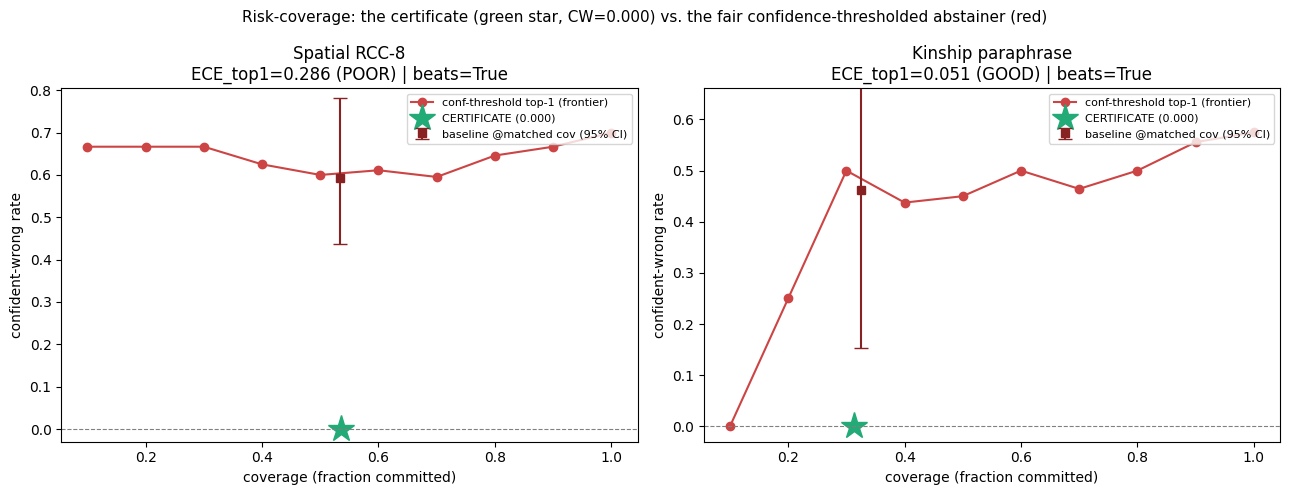

In [12]:
def summarize(name, s):
    cb = s["conf_threshold_baseline"]; cert = s["certificate"]; cm = s["commit_argmax"]; mb = s["modeB"]
    print(f"\n=== {name} ===")
    print(f"  certificate (abstain-on-collapse): confident-wrong {cert['confident_wrong']:.4f} @cov {cert['coverage']:.4f}")
    print(f"  commit-argmax (always-answer):     confident-wrong {cm['confident_wrong']:.4f} @cov {cm['coverage']:.4f}")
    print(f"  CONFIDENCE-THRESHOLD @matched cov: confident-wrong {cb['confident_wrong']:.4f} "
          f"95% CI [{cb['ci95'][0]:.4f}, {cb['ci95'][1]:.4f}] @cov {cb['achieved_coverage']:.4f}")
    print(f"      implied tau={cb['implied_tau']}  ECE_top1={s['ECE_top1']:.4f} ({s['calibration_quality']})")
    print(f"  ->  certificate_beats (CI lower bound > 0): {cb['certificate_beats']}")
    print(f"  Mode-B: {mb['n_caught']}/{mb['n_unsound_query_pool']} unsound queries caught, "
          f"{mb['n_silent_wrong_missed']} silent-wrong missed"
          + ("" if not mb['modeB_untested'] else "  (UNTESTED: 0 unsound reads)"))

summarize("Spatial RCC-8", spatial)
summarize("Kinship paraphrase", kinship)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (name, s) in zip(axes, [("Spatial RCC-8", spatial), ("Kinship paraphrase", kinship)]):
    cb = s["conf_threshold_baseline"]; cert = s["certificate"]
    fr = [p for p in cb["frontier"] if not p.get("matched_point")]
    fr = sorted(fr, key=lambda p: p["achieved_coverage"])
    xs = [p["achieved_coverage"] for p in fr]
    ys = [p["confident_wrong"] for p in fr]
    ax.plot(xs, ys, "o-", color="#c44", label="conf-threshold top-1 (frontier)")
    # matched-coverage baseline point + bootstrap CI
    ax.errorbar([cb["achieved_coverage"]], [cb["confident_wrong"]],
                yerr=[[cb["confident_wrong"] - cb["ci95"][0]], [cb["ci95"][1] - cb["confident_wrong"]]],
                fmt="s", color="#822", capsize=5, label="baseline @matched cov (95% CI)")
    # certificate point
    ax.plot([cert["coverage"]], [cert["confident_wrong"]], "*", ms=20, color="#2a7",
            label="CERTIFICATE (0.000)")
    ax.axhline(0.0, color="gray", lw=0.8, ls="--")
    ax.set_title(f"{name}\nECE_top1={s['ECE_top1']:.3f} ({s['calibration_quality']}) | "
                 f"beats={cb['certificate_beats']}")
    ax.set_xlabel("coverage (fraction committed)")
    ax.set_ylabel("confident-wrong rate")
    ax.set_ylim(-0.03, max(0.1, max(ys) * 1.15))
    ax.legend(fontsize=8, loc="upper right")
fig.suptitle("Risk-coverage: the certificate (green star, CW=0.000) vs. the fair "
             "confidence-thresholded abstainer (red)", fontsize=11)
fig.tight_layout()
plt.show()